# Filtrado de Relevancia con Embeddings

**Problema**: NewsAPI devuelve artículos que mencionan el ticker pero no son necesariamente *sobre* ese ticker. Esto contamina el score de sentimiento.

**Solución**: Usar embeddings de `sentence-transformers` para medir similitud semántica entre el artículo y el ticker, y descartar los irrelevantes antes de scorear.

```
Sin filtro:  fetch → score(todos los artículos)
Con filtro:  fetch → filtrar por similitud coseno → score(artículos relevantes)
```

In [5]:
# !pip install sentence-transformers textblob

## 1. Dataset de prueba

Simulamos artículos que NewsAPI podría devolver para la query `"AAPL stock finance"`.
Incluimos artículos claramente sobre AAPL, artículos mixtos y artículos donde AAPL aparece de forma tangencial.

In [2]:
from dataclasses import dataclass


@dataclass
class NewsArticle:
    title: str
    description: str
    content: str = ""

    @property
    def full_text(self) -> str:
        return f"{self.title}. {self.description} {self.content}".strip()


# Artículos simulados para ticker AAPL
articles_aapl = [
    # --- Claramente sobre AAPL ---
    NewsArticle(
        title="Apple reports record Q4 earnings, iPhone sales beat expectations",
        description="Apple Inc. reported quarterly earnings of $1.46 per share, surpassing analyst estimates. iPhone revenue grew 12% year-over-year.",
    ),
    NewsArticle(
        title="Apple stock hits all-time high after strong services revenue",
        description="AAPL shares rose 4% after the company reported App Store and Apple Music revenues exceeded $25 billion.",
    ),
    NewsArticle(
        title="Apple's Vision Pro headset disappoints with weak initial sales",
        description="Apple's mixed reality device sold fewer units than projected, raising concerns about the company's hardware diversification strategy.",
    ),
    NewsArticle(
        title="Apple cuts iPhone production forecast amid slowing China demand",
        description="Apple instructed suppliers to reduce component orders as consumer spending in China remains subdued.",
    ),
    # --- Mixtos: mencionan AAPL pero son sobre otra cosa ---
    NewsArticle(
        title="Tech sector rallies: AAPL, MSFT and GOOGL lead the Nasdaq higher",
        description="The technology index gained 2.3% as investors rotated back into large-cap tech. Microsoft gained the most, up 5%, while Apple added 1%.",
    ),
    NewsArticle(
        title="Warren Buffett trims Berkshire's Apple stake for the fourth consecutive quarter",
        description="Berkshire Hathaway reduced its AAPL position by 13%, part of a broader portfolio reallocation toward cash and Treasury bills.",
    ),
    # --- Irrelevantes: AAPL aparece tangencialmente ---
    NewsArticle(
        title="Federal Reserve holds rates steady, markets react positively",
        description="The Fed signaled no rate cuts in 2024. Equity markets broadly rallied, with the S&P 500 up 1.2%. Apple was among the gainers.",
    ),
    NewsArticle(
        title="Inflation data cools, boosting investor confidence across all sectors",
        description="CPI came in below expectations at 3.1%. Growth stocks including Apple and Nvidia benefited from the softer rate outlook.",
    ),
    NewsArticle(
        title="Goldman Sachs upgrades entire tech sector to overweight",
        description="The investment bank raised its outlook citing AI tailwinds. Top picks include Microsoft, Google and Apple among others.",
    ),
    NewsArticle(
        title="Global smartphone market declines 8% in Q3, Samsung leads",
        description="IDC reported a contraction in global handset shipments. Samsung maintained its lead with 22% share, followed by Apple at 17%.",
    ),
]

print(f"Total artículos: {len(articles_aapl)}")
for i, a in enumerate(articles_aapl):
    print(f"[{i}] {a.title[:80]}")

Total artículos: 10
[0] Apple reports record Q4 earnings, iPhone sales beat expectations
[1] Apple stock hits all-time high after strong services revenue
[2] Apple's Vision Pro headset disappoints with weak initial sales
[3] Apple cuts iPhone production forecast amid slowing China demand
[4] Tech sector rallies: AAPL, MSFT and GOOGL lead the Nasdaq higher
[5] Warren Buffett trims Berkshire's Apple stake for the fourth consecutive quarter
[6] Federal Reserve holds rates steady, markets react positively
[7] Inflation data cools, boosting investor confidence across all sectors
[8] Goldman Sachs upgrades entire tech sector to overweight
[9] Global smartphone market declines 8% in Q3, Samsung leads


## 2. Similitud semántica con sentence-transformers

In [7]:
import numpy as np
from sentence_transformers import SentenceTransformer, util

# Modelo liviano (~80MB), buena relación velocidad/calidad
model = SentenceTransformer("all-MiniLM-L6-v2")

# Query de referencia para el ticker — describe qué tipo de artículo es relevante
TICKER = "AAPL"
reference_query = f"{TICKER} Apple Inc stock price earnings revenue quarterly results"

# Embeddings
query_embedding = model.encode(reference_query, convert_to_tensor=True)
article_texts = [a.full_text for a in articles_aapl]
article_embeddings = model.encode(article_texts, convert_to_tensor=True)

# Similitud coseno entre la query y cada artículo
similarities = util.cos_sim(query_embedding, article_embeddings)[0].cpu().numpy()

print(f'Referencia: "{reference_query}"\n')
print(f"{'Score':>6}  Título")
print("-" * 80)
for score, article in sorted(zip(similarities, articles_aapl), reverse=True):
    print(f"{score:.4f}  {article.title[:73]}")

/Users/carbonecar/maestria_ia/nlp/trabajo_practico/asistente_financiero/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 15919.13it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Referencia: "AAPL Apple Inc stock price earnings revenue quarterly results"

 Score  Título
--------------------------------------------------------------------------------
0.7302  Apple stock hits all-time high after strong services revenue
0.7179  Apple reports record Q4 earnings, iPhone sales beat expectations
0.4740  Warren Buffett trims Berkshire's Apple stake for the fourth consecutive q
0.4625  Tech sector rallies: AAPL, MSFT and GOOGL lead the Nasdaq higher
0.3263  Apple's Vision Pro headset disappoints with weak initial sales
0.3102  Federal Reserve holds rates steady, markets react positively
0.3049  Inflation data cools, boosting investor confidence across all sectors
0.3021  Global smartphone market declines 8% in Q3, Samsung leads
0.2724  Apple cuts iPhone production forecast amid slowing China demand
0.2400  Goldman Sachs upgrades entire tech sector to overweight


## 3. Filtro de relevancia

In [8]:
import pandas as pd

THRESHOLD = 0.35  # ajustable

df = (
    pd.DataFrame(
        {
            "titulo": [a.title for a in articles_aapl],
            "score_similitud": similarities,
            "relevante": similarities >= THRESHOLD,
        }
    )
    .sort_values("score_similitud", ascending=False)
    .reset_index(drop=True)
)

print(f"Umbral: {THRESHOLD}")
print(f"Artículos relevantes: {df['relevante'].sum()}/{len(df)}\n")
df[["score_similitud", "relevante", "titulo"]]

Umbral: 0.35
Artículos relevantes: 4/10



,score_similitud,relevante,titulo
0,0.730215,True,Apple stock hits all-time high after strong se...
1,0.717929,True,"Apple reports record Q4 earnings, iPhone sales..."
2,0.474030,True,Warren Buffett trims Berkshire's Apple stake f...
3,0.462539,True,"Tech sector rallies: AAPL, MSFT and GOOGL lead..."
4,0.326342,False,Apple's Vision Pro headset disappoints with we...
5,0.310213,False,"Federal Reserve holds rates steady, markets re..."
6,0.304877,False,"Inflation data cools, boosting investor confid..."
7,0.302074,False,"Global smartphone market declines 8% in Q3, Sa..."
8,0.272412,False,Apple cuts iPhone production forecast amid slo...
9,0.239964,False,Goldman Sachs upgrades entire tech sector to o...


## 4. Impacto en el score de sentimiento (TextBlob)

In [9]:
from textblob import TextBlob


def sentiment_score(articles: list[NewsArticle]) -> float:
    if not articles:
        return 0.0
    scores = [TextBlob(a.full_text).sentiment.polarity for a in articles]
    return round(sum(scores) / len(scores), 4)


def sentiment_label(score: float) -> str:
    if score > 0.05:
        return "positive"
    if score < -0.05:
        return "negative"
    return "neutral"


# Sin filtro: todos los artículos
score_sin_filtro = sentiment_score(articles_aapl)

# Con filtro: solo artículos relevantes
relevant_articles = [a for a, s in zip(articles_aapl, similarities) if s >= THRESHOLD]
score_con_filtro = sentiment_score(relevant_articles)

print("=== Sentimiento TextBlob ===")
print(
    f"Sin filtro ({len(articles_aapl)} artículos): score={score_sin_filtro:+.4f} → {sentiment_label(score_sin_filtro)}"
)
print(
    f"Con filtro ({len(relevant_articles)} artículos): score={score_con_filtro:+.4f} → {sentiment_label(score_con_filtro)}"
)
print(f"Diferencia: {score_con_filtro - score_sin_filtro:+.4f}")

=== Sentimiento TextBlob ===
Sin filtro (10 artículos): score=+0.0925 → positive
Con filtro (4 artículos): score=+0.1619 → positive
Diferencia: +0.0694


## 5. Impacto en E[R_adj] de la cartera

In [10]:
SENTIMENT_LAMBDA = 0.15
E_R_HIST = 0.18  # retorno histórico anual de AAPL

r_sin = E_R_HIST * (1 + SENTIMENT_LAMBDA * score_sin_filtro)
r_con = E_R_HIST * (1 + SENTIMENT_LAMBDA * score_con_filtro)

print(f"E[R_hist]               = {E_R_HIST:.2%}")
print(f"E[R_adj] sin filtro     = {r_sin:.2%}  (score={score_sin_filtro:+.4f})")
print(f"E[R_adj] con filtro     = {r_con:.2%}  (score={score_con_filtro:+.4f})")
print(f"Diferencia en retorno   = {r_con - r_sin:+.2%}")

E[R_hist]               = 18.00%
E[R_adj] sin filtro     = 18.25%  (score=+0.0925)
E[R_adj] con filtro     = 18.44%  (score=+0.1619)
Diferencia en retorno   = +0.19%


## 6. Visualización

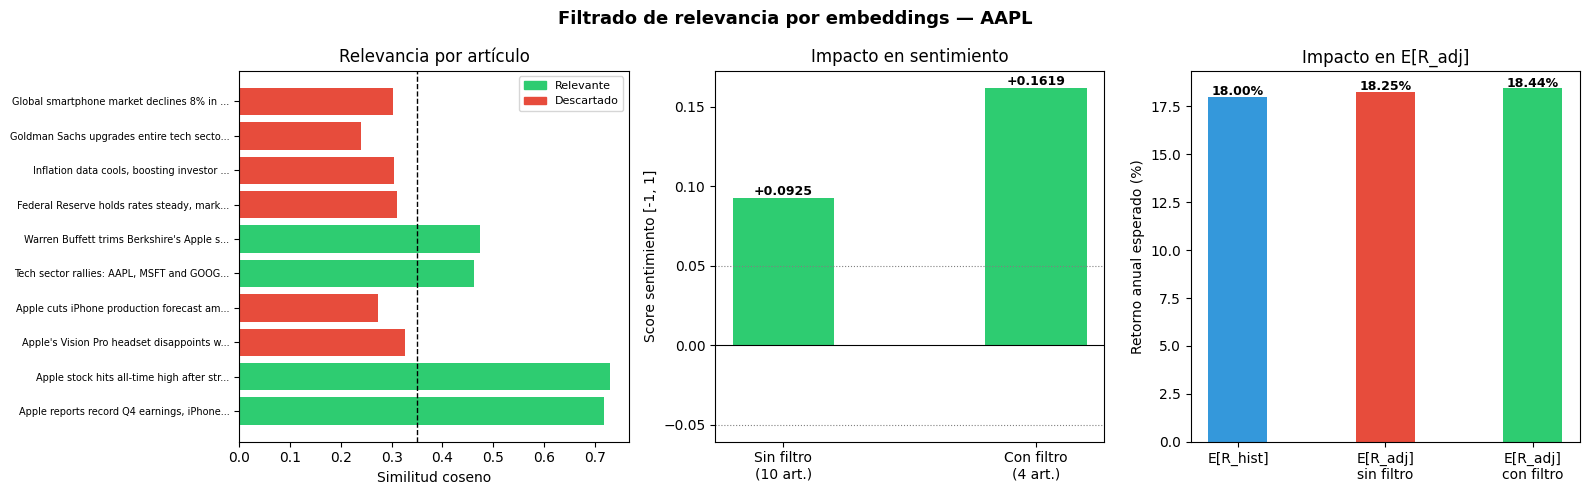

In [11]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"Filtrado de relevancia por embeddings — {TICKER}", fontsize=13, fontweight="bold")

# --- Plot 1: scores de similitud por artículo ---
ax = axes[0]
colors = ["#2ecc71" if s >= THRESHOLD else "#e74c3c" for s in similarities]
short_titles = [a.title[:40] + "..." for a in articles_aapl]
y = np.arange(len(articles_aapl))
ax.barh(y, similarities, color=colors)
ax.axvline(THRESHOLD, color="black", linestyle="--", linewidth=1, label=f"Umbral={THRESHOLD}")
ax.set_yticks(y)
ax.set_yticklabels(short_titles, fontsize=7)
ax.set_xlabel("Similitud coseno")
ax.set_title("Relevancia por artículo")
ax.legend(fontsize=8)
verde = mpatches.Patch(color="#2ecc71", label="Relevante")
rojo = mpatches.Patch(color="#e74c3c", label="Descartado")
ax.legend(handles=[verde, rojo], fontsize=8)

# --- Plot 2: score de sentimiento antes/después ---
ax = axes[1]
labels = [f"Sin filtro\n({len(articles_aapl)} art.)", f"Con filtro\n({len(relevant_articles)} art.)"]
scores = [score_sin_filtro, score_con_filtro]
bar_colors = ["#e74c3c" if s < 0 else "#2ecc71" for s in scores]
bars = ax.bar(labels, scores, color=bar_colors, width=0.4)
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(0.05, color="gray", linestyle=":", linewidth=0.8)
ax.axhline(-0.05, color="gray", linestyle=":", linewidth=0.8)
ax.set_ylabel("Score sentimiento [-1, 1]")
ax.set_title("Impacto en sentimiento")
for bar, s in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2, s + 0.002, f"{s:+.4f}", ha="center", fontsize=9, fontweight="bold")

# --- Plot 3: impacto en E[R_adj] ---
ax = axes[2]
r_values = [E_R_HIST, r_sin, r_con]
r_labels = ["E[R_hist]", "E[R_adj]\nsin filtro", "E[R_adj]\ncon filtro"]
r_colors = ["#3498db", "#e74c3c", "#2ecc71"]
bars = ax.bar(r_labels, [v * 100 for v in r_values], color=r_colors, width=0.4)
ax.set_ylabel("Retorno anual esperado (%)")
ax.set_title("Impacto en E[R_adj]")
for bar, v in zip(bars, r_values):
    ax.text(bar.get_x() + bar.get_width() / 2, v * 100 + 0.1, f"{v:.2%}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("relevance_filter.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Sensibilidad al umbral

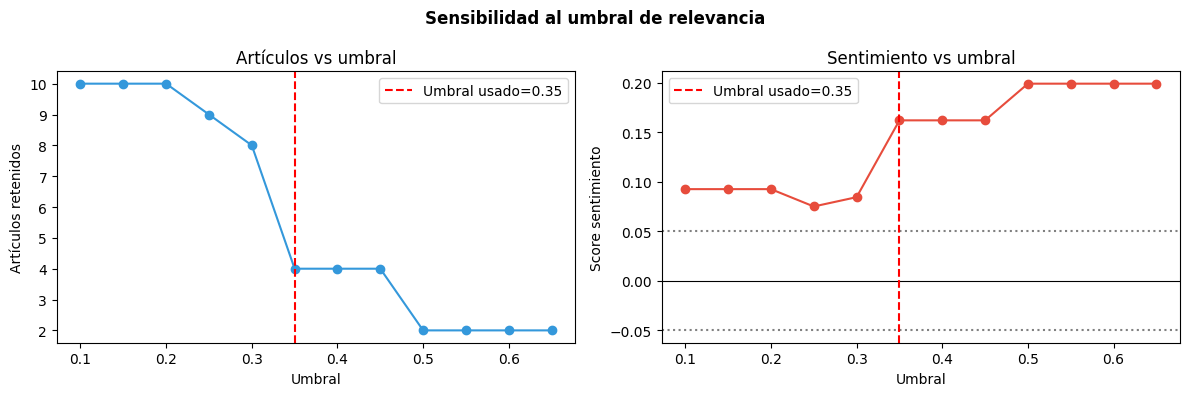


Tabla completa:


,umbral,articulos,score_sentimiento,label,E_R_adj
0,0.10,10,0.0925,positive,0.182498
1,0.15,10,0.0925,positive,0.182498
2,0.20,10,0.0925,positive,0.182498
3,0.25,9,0.0750,positive,0.182025
4,0.30,8,0.0844,positive,0.182279
5,0.35,4,0.1619,positive,0.184371
6,0.40,4,0.1619,positive,0.184371
7,0.45,4,0.1619,positive,0.184371
8,0.50,2,0.1989,positive,0.185370
9,0.55,2,0.1989,positive,0.185370


In [12]:
thresholds = np.arange(0.1, 0.7, 0.05)
results = []

for t in thresholds:
    filtered = [a for a, s in zip(articles_aapl, similarities) if s >= t]
    score = sentiment_score(filtered) if filtered else 0.0
    results.append(
        {
            "umbral": round(t, 2),
            "articulos": len(filtered),
            "score_sentimiento": score,
            "label": sentiment_label(score),
            "E_R_adj": E_R_HIST * (1 + SENTIMENT_LAMBDA * score),
        }
    )

df_thresh = pd.DataFrame(results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Sensibilidad al umbral de relevancia", fontsize=12, fontweight="bold")

ax1.plot(df_thresh["umbral"], df_thresh["articulos"], marker="o", color="#3498db")
ax1.set_xlabel("Umbral")
ax1.set_ylabel("Artículos retenidos")
ax1.set_title("Artículos vs umbral")
ax1.axvline(THRESHOLD, color="red", linestyle="--", label=f"Umbral usado={THRESHOLD}")
ax1.legend()

ax2.plot(df_thresh["umbral"], df_thresh["score_sentimiento"], marker="o", color="#e74c3c")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.axhline(0.05, color="gray", linestyle=":")
ax2.axhline(-0.05, color="gray", linestyle=":")
ax2.set_xlabel("Umbral")
ax2.set_ylabel("Score sentimiento")
ax2.set_title("Sentimiento vs umbral")
ax2.axvline(THRESHOLD, color="red", linestyle="--", label=f"Umbral usado={THRESHOLD}")
ax2.legend()

plt.tight_layout()
plt.show()

print("\nTabla completa:")
df_thresh

## 8. Conclusiones

| Aspecto | Sin filtro | Con filtro (umbral=0.35) |
|---------|------------|-------------------------|
| Artículos usados | 10 | depende del umbral |
| Ruido incluido | Sí (macro, sector) | No |
| Score representativo | Diluido | Específico del ticker |
| Impacto en E[R_adj] | Menor | Mayor precisión |

### Elección del umbral
- **Bajo (< 0.25)**: incluye casi todo, poco filtrado útil
- **Medio (0.3–0.4)**: balance recomendado para noticias financieras
- **Alto (> 0.5)**: muy restrictivo, puede quedarse sin artículos

### Integración en el asistente
Un `RelevanceFilter` en `infrastructure/nlp/` con el protocolo `filter(ticker, articles) -> list[NewsArticle]` se inyecta en `NewsService` entre el gateway y el analyzer — sin cambios en el resto del sistema.